In [8]:
# Copyright [2025] [KTH Royal Institute of Technology] 
# Licensed under the Educational Community License, Version 2.0 (ECL-2.0)
# This file is part of the materials for EL2805 - Reinforcement Learning - Exercise Session 3 at KTH, Stockholm.

import numpy as np
import gymnasium as gym
from collections import deque, namedtuple
import torch
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.tensorboard import SummaryWriter

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import ListedColormap, BoundaryNorm

# from DQN_agent import Agent
# from Agent import MyNetwork

In [9]:
model = torch.load('neural-network-1.pth', weights_only=False)
print('Network model: {}'.format(model))

Network model: MyNetwork(
  (layers): ModuleList(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=4, bias=True)
  )
  (activation): ReLU()
)


In [10]:
n = 100
Y = np.linspace(0, 1.5, n)
W = np.linspace(-np.pi, np.pi, n)
Y, W = np.meshgrid(Y, W)
N = Y.size

states = np.zeros((N, 8), dtype=np.float32)
states[:, 1] = Y.ravel()
states[:, 4] = W.ravel()

In [11]:
model.eval()

with torch.no_grad():
    states_t = torch.from_numpy(states)
    Q = model(states_t)          # shape (N, 4)
    Q_max, a_max = Q.max(dim=1)  # shape (N,)

Z = Q_max.numpy().reshape(Y.shape)
A_grid = a_max.numpy().reshape(Y.shape)

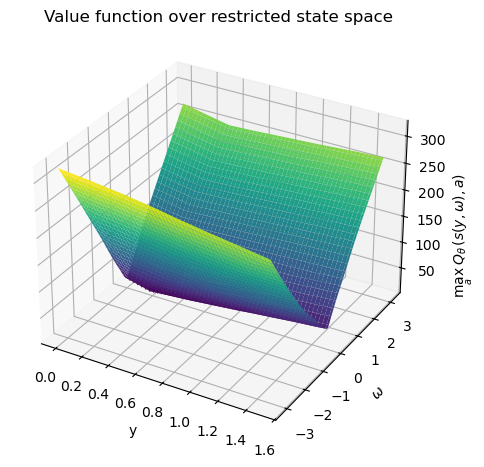

In [12]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(Y, W, Z, cmap="viridis", linewidth=0, antialiased=True)

ax.set_xlabel("y")
ax.set_ylabel("$\\omega$")
ax.set_zlabel("")  # disable native z-label
ax.set_title("Value function over restricted state space")

# Reserve space on the right
fig.subplots_adjust(right=0.82)

# Place z-label outside ticks
fig.text(
    0.88, 0.5, "$\\max_a \\: Q_\\theta(s(y,\\omega),a)$",
    rotation=90,
    va="center",
    ha="center"
)

plt.show()
fig.savefig("plots/3D_value_func_DQN.png")

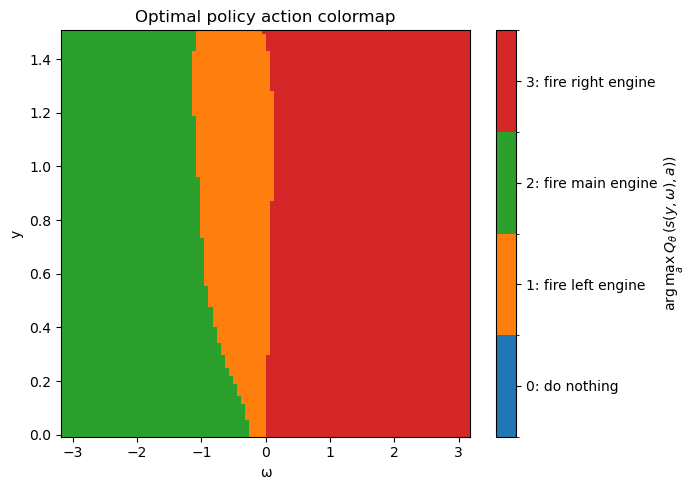

In [13]:
cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green", "tab:red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig = plt.figure(figsize=(7, 5))
plt.pcolormesh(W, Y, A_grid, cmap=cmap, norm=norm, shading="nearest")

cbar = plt.colorbar(ticks=[0, 1, 2, 3])
cbar.ax.set_yticklabels([
    "0: do nothing",
    "1: fire left engine",
    "2: fire main engine",
    "3: fire right engine",
])
cbar.set_label("$\\arg\\max_a \\: Q_\\theta(s(y,\\omega),a))$")

plt.xlabel("ω")
plt.ylabel("y")

plt.title("Optimal policy action colormap")

plt.tight_layout()
plt.show()

fig.savefig("plots/action_colormap_DQN.png")


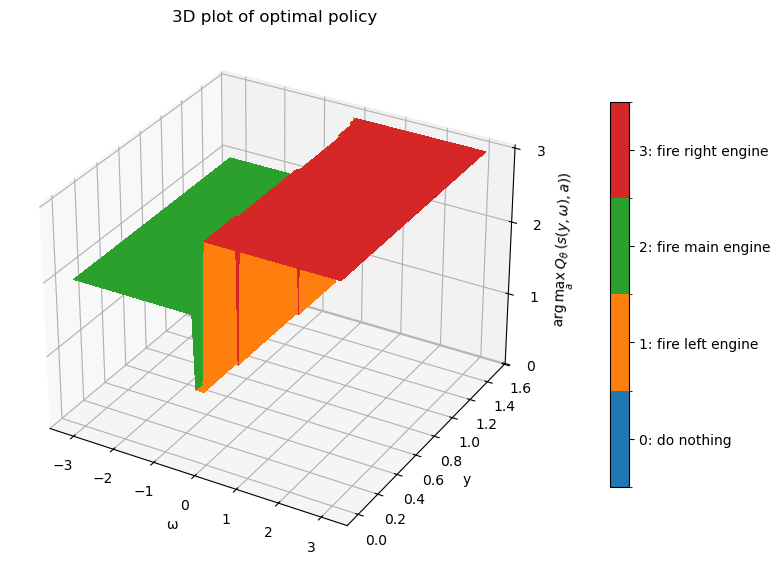

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import numpy as np

cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green", "tab:red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

# Z is the discrete action index
Z = A_grid.astype(float)

# Map actions to RGBA colors for the surface
facecolors = cmap(norm(Z))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    W, Y, Z,
    facecolors=facecolors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=False,
    shade=False,
)

ax.set_xlabel("ω")
ax.set_ylabel("y")
ax.set_zlabel("$\\arg\\max_a \\: Q_\\theta(s(y,\\omega),a))$")

# Fix z-axis ticks to the discrete actions
ax.set_zticks([0, 1, 2, 3])
# ax.set_zticklabels([
#     "do nothing",
#     "fire left engine",
#     "fire main engine",
#     "fire right engine",
# ])

# Separate colorbar (same as 2D semantics)
mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
mappable.set_array([])

cbar = fig.colorbar(
    mappable,
    ax=ax,                 # ← THIS is the missing piece
    ticks=[0, 1, 2, 3],
    shrink=0.7,
    pad=0.1,
)
cbar.ax.set_yticklabels([
    "0: do nothing",
    "1: fire left engine",
    "2: fire main engine",
    "3: fire right engine",
])
# cbar.set_label("$\\arg\\max_a Q_\\theta(s(y,\\omega),a))$")

ax.set_title("3D plot of optimal policy")

plt.tight_layout()
plt.show()

fig.savefig("plots/3D_policy_DQN.png")